In [1]:
%pip install music21

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.signal import medfilt
from collections import Counter
from scipy.ndimage import median_filter
import music21

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from collections import Counter

def frequency_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def get_midi_contour_from_csv(csv_fn, low_pitch=41, high_pitch=77):
    df = pd.read_csv(csv_fn)
    df.columns = ["time", "frequency", "confidence"]
    frequency = df['frequency'].values
    confidence = df['confidence'].values
    threshold = 0.7
    frequency[confidence < threshold] = np.nan
    filtered_frequency = median_filter(frequency, size=5, mode='nearest')

    pitch_in_midi = [frequency_to_midi(freq) for freq in filtered_frequency]
    midi_notes = [x for x in pitch_in_midi if low_pitch <= x < high_pitch]

    return midi_notes

def compensate_tuning(midi_notes):
    max_appearance = 0
    best_comp = 0
    best_midi_notes = []

    for compensate in (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9):
        adjusted_midi = [round(midi + compensate) for midi in midi_notes]
        common_pitch, num_appearance = Counter(adjusted_midi).most_common(1)[0]

        if num_appearance > max_appearance:
            max_appearance = num_appearance
            best_comp = compensate
            best_midi_notes = adjusted_midi

    return best_midi_notes, best_comp

def get_histogram(midi_notes, bin_size=0.25, best_comp=0.0):
    unique_notes, counts = np.unique(midi_notes, return_counts=True)
    max_sum = 0
    best_tonic = unique_notes[0]

    for note in unique_notes:
        shifted_note = note + 7
        total_count = counts[np.where(unique_notes == note)].sum()

        if shifted_note in unique_notes:
            total_count += counts[np.where(unique_notes == shifted_note)].sum()

        if total_count > max_sum:
            max_sum = total_count
            best_tonic = note

    lowest_edge = best_tonic - 12.5 - bin_size / 2
    highest_edge = best_tonic + 12.5 + bin_size / 2

    edges = np.arange(lowest_edge, highest_edge + bin_size, bin_size)
    bins = edges[:-1] + bin_size / 2

    edges, bins

    edges = np.arange(best_tonic - 12.5, best_tonic + 12.5 + bin_size, bin_size)

    if len(midi_notes) == 0:
        return np.zeros(len(edges) - 1)

    hist = np.histogram(midi_notes, bins=edges, density=False)[0]


    return hist, edges

file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/F0'
output_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/Histogram/FullVocal_7th'

os.makedirs(output_path, exist_ok=True)

for file_name in os.listdir(file_path):
    if file_name.endswith(".csv"):
        f0_path = os.path.join(file_path, file_name)

        midi_notes = get_midi_contour_from_csv(f0_path)

        midi_notes, best_comp = compensate_tuning(midi_notes)

        if len(midi_notes) > 0:
            histogram, edges = get_histogram(midi_notes, best_comp = best_comp)

            print(histogram)

            edges = np.array(edges)

            bin_centers = (edges[:-1] + edges[1:]) / 2

            plt.figure(figsize=(10, 6))

            plt.bar(bin_centers, histogram, width=0.25, align = 'center', alpha=1.0, color = 'blue', edgecolor = 'black')

            plt.xticks(edges[::4], labels=[f"{e:.2f}" for e in edges[::4]], rotation=45)
            plt.xlabel("Interval (Semitones)")
            plt.ylabel("Probability Density")
            plt.title(f"Normalized Pitch Histogram - {file_name}")
            plt.grid(axis="y", linestyle="--", alpha=0.7)

            save_path = os.path.join(output_path, f"{os.path.splitext(file_name)[0]}_normalized.png")
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close()

[  0   0  61   0   0   0  50   0   0   0  37   0   0   0  39   0   0   0
  22   0   0   0  45   0   0   0  68   0   0   0 183   0   0   0  69   0
   0   0  60   0   0   0 134   0   0   0  88   0   0   0 157   0   0   0
 438   0   0   0 347   0   0   0 420   0   0   0 452   0   0   0 593   0
   0   0 380   0   0   0 784   0   0   0 298   0   0   0 181   0   0   0
  92   0   0   0  61   0   0   0  75   0]


/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 48317 (\N{HANGUL SYLLABLE BYEOG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG

[   0    0  150    0    0    0   88    0    0    0   61    0    0    0
   20    0    0    0   75    0    0    0  166    0    0    0  283    0
    0    0  274    0    0    0  184    0    0    0  197    0    0    0
  178    0    0    0  800    0    0    0 2436    0    0    0 1095    0
    0    0  881    0    0    0  922    0    0    0  958    0    0    0
  473    0    0    0  634    0    0    0  867    0    0    0  317    0
    0    0  164    0    0    0   56    0    0    0   35    0    0    0
   69    0]


/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 52632 (\N{HANGUL SYLLABLE CUN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) m

[   0    0  241    0    0    0  207    0    0    0  165    0    0    0
  212    0    0    0  341    0    0    0  467    0    0    0  802    0
    0    0  549    0    0    0  424    0    0    0  873    0    0    0
  702    0    0    0 1209    0    0    0 3946    0    0    0 2409    0
    0    0 1702    0    0    0 1799    0    0    0 2229    0    0    0
 2272    0    0    0 2740    0    0    0 2008    0    0    0 1717    0
    0    0  538    0    0    0  300    0    0    0  565    0    0    0
  788    0]
[  0   0   0   0   0   0   1   0   0   0   3   0   0   0   2   0   0   0
   0   0   0   0   4   0   0   0   6   0   0   0  10   0   0   0   9   0
   0   0  13   0   0   0   8   0   0   0 112   0   0   0  92   0   0   0
  36   0   0   0   9   0   0   0  19   0   0   0  18   0   0   0  36   0
   0   0  55   0   0   0 202   0   0   0  65   0   0   0   3   0   0   0
   0   0   0   0   1   0   0   0   1   0]


...

/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 52285 (\N{HANGUL SYLLABLE CANG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 52632 (\N{HANGUL SYLLABLE CUN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) 

[   0    0   33    0    0    0   19    0    0    0    7    0    0    0
    0    0    0    0   18    0    0    0    6    0    0    0  104    0
    0    0  237    0    0    0   93    0    0    0  105    0    0    0
   60    0    0    0  336    0    0    0 2283    0    0    0 1163    0
    0    0 1192    0    0    0  438    0    0    0  288    0    0    0
  378    0    0    0  215    0    0    0  776    0    0    0  453    0
    0    0   95    0    0    0   24    0    0    0   50    0    0    0
   94    0]


/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 52632 (\N{HANGUL SYLLABLE CUN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 54413 (\N{HANGUL SYLLABLE PUNG}) mi

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   2   0   0   0   0   0   0   0   0   0   0   0  11   0   0   0
  13   0   0   0  16   0   0   0   8   0   0   0   0   0   0   0   8   0
   0   0   8   0   0   0 320   0   0   0  52   0   0   0  16   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    6    0    0    0   14    0    0    0   84    0    0    0  223    0
    0    0  317    0    0    0  408    0    0    0   85    0    0    0
  135    0    0    0  819    0    0    0 2203    0    0    0 1139    0
    0    0 1029    0    0    0  426    0    0    0  562    0    0    0
  519    0    0    0  487    0    0    0  557    0    0    0  822    0
    0    0  335    0    0    0   38    0    0    0   24    0    0    0
   71    0]


/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 44417 (\N{HANGUL SYLLABLE GUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_176528/2263762599.py:108: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missi

In [ ]:
def extract_midi_pitches_from_musicxml(xml_path):
    score = music21.converter.parse(xml_path)
    midi_pitches = []

    for note in score.recurse().notes:
        if isinstance(note, music21.note.Note):
            midi_pitches.append(note.pitch.midi)

    return midi_pitches

# 군사 설움 타령 아내 생각 

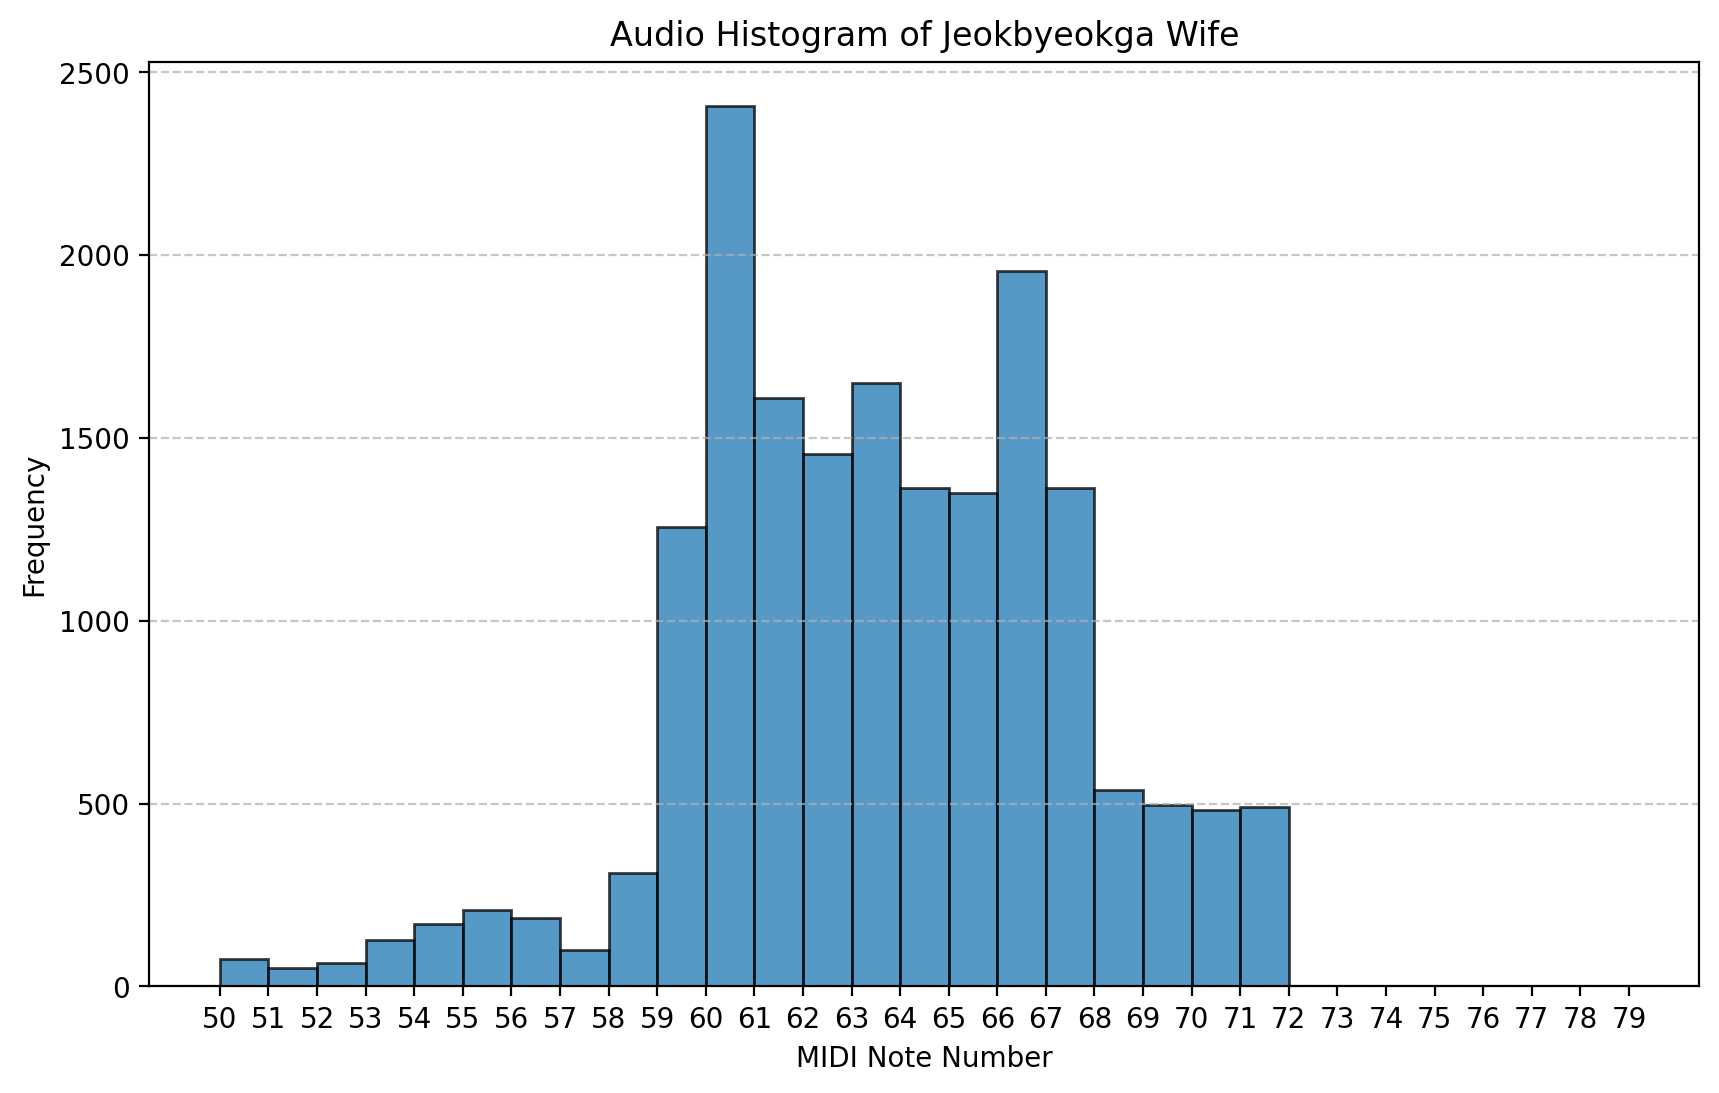

In [41]:
file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/군사 설움 타령 아내 생각 중머리.csv'

midi_notes = get_midi_contour_from_csv(file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_notes, bins=np.arange(50, 80), edgecolor='black', alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("Audio Histogram of Jeokbyeokga Wife")
plt.xticks(np.arange(50, 80))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [26]:
xml_file_path = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/11-3-a.musicxml"

midi_pitches = extract_midi_pitches_from_musicxml(xml_file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_pitches, bins=np.arange(50, 80) - 0.5, edgecolor="black", alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("XML Histogram of Jeokbyeokga Wife")
plt.xticks(np.arange(50, 80))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

NameError: name 'extract_midi_pitches_from_musicxml' is not defined

# 정욱과 조조 군사 탄식 

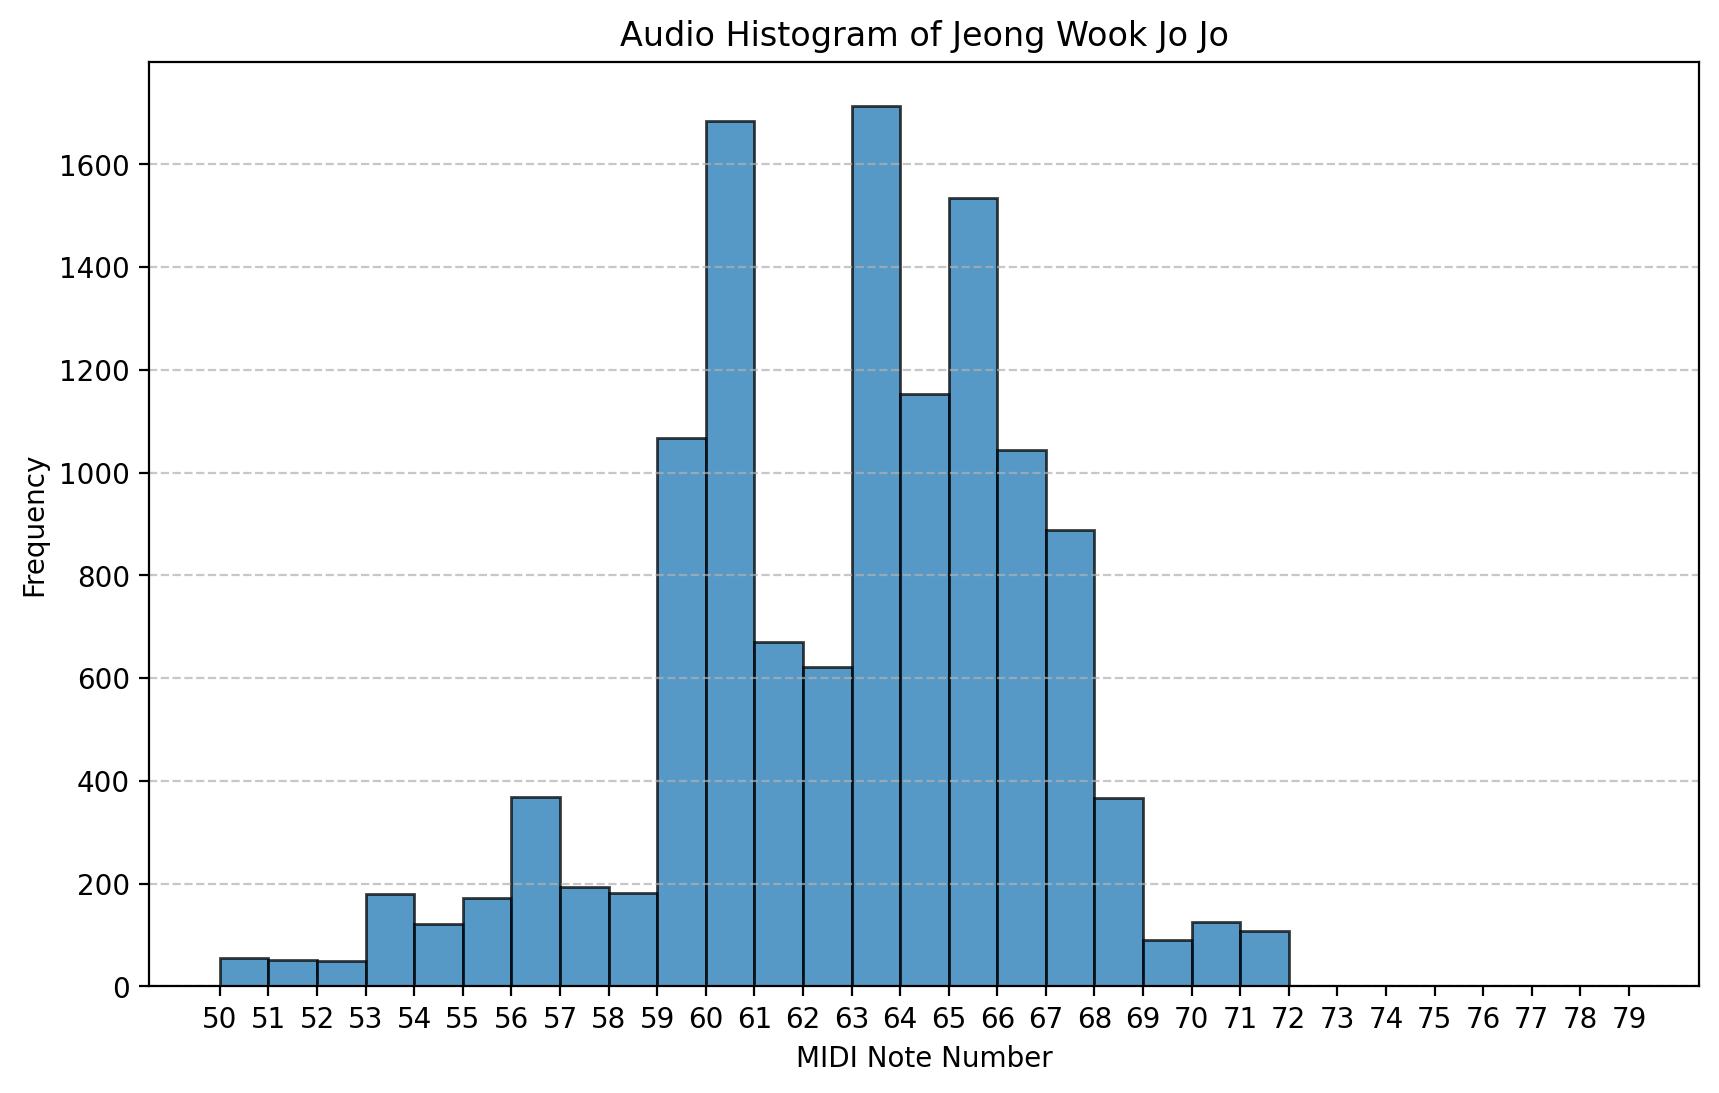

In [35]:
file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/정욱과 조조 군사 탄식 중머리.csv'

midi_notes = get_midi_contour_from_csv(file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_notes, bins=np.arange(50, 80), edgecolor='black', alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("Audio Histogram of Jeong Wook Jo Jo")
plt.xticks(np.arange(50, 80))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

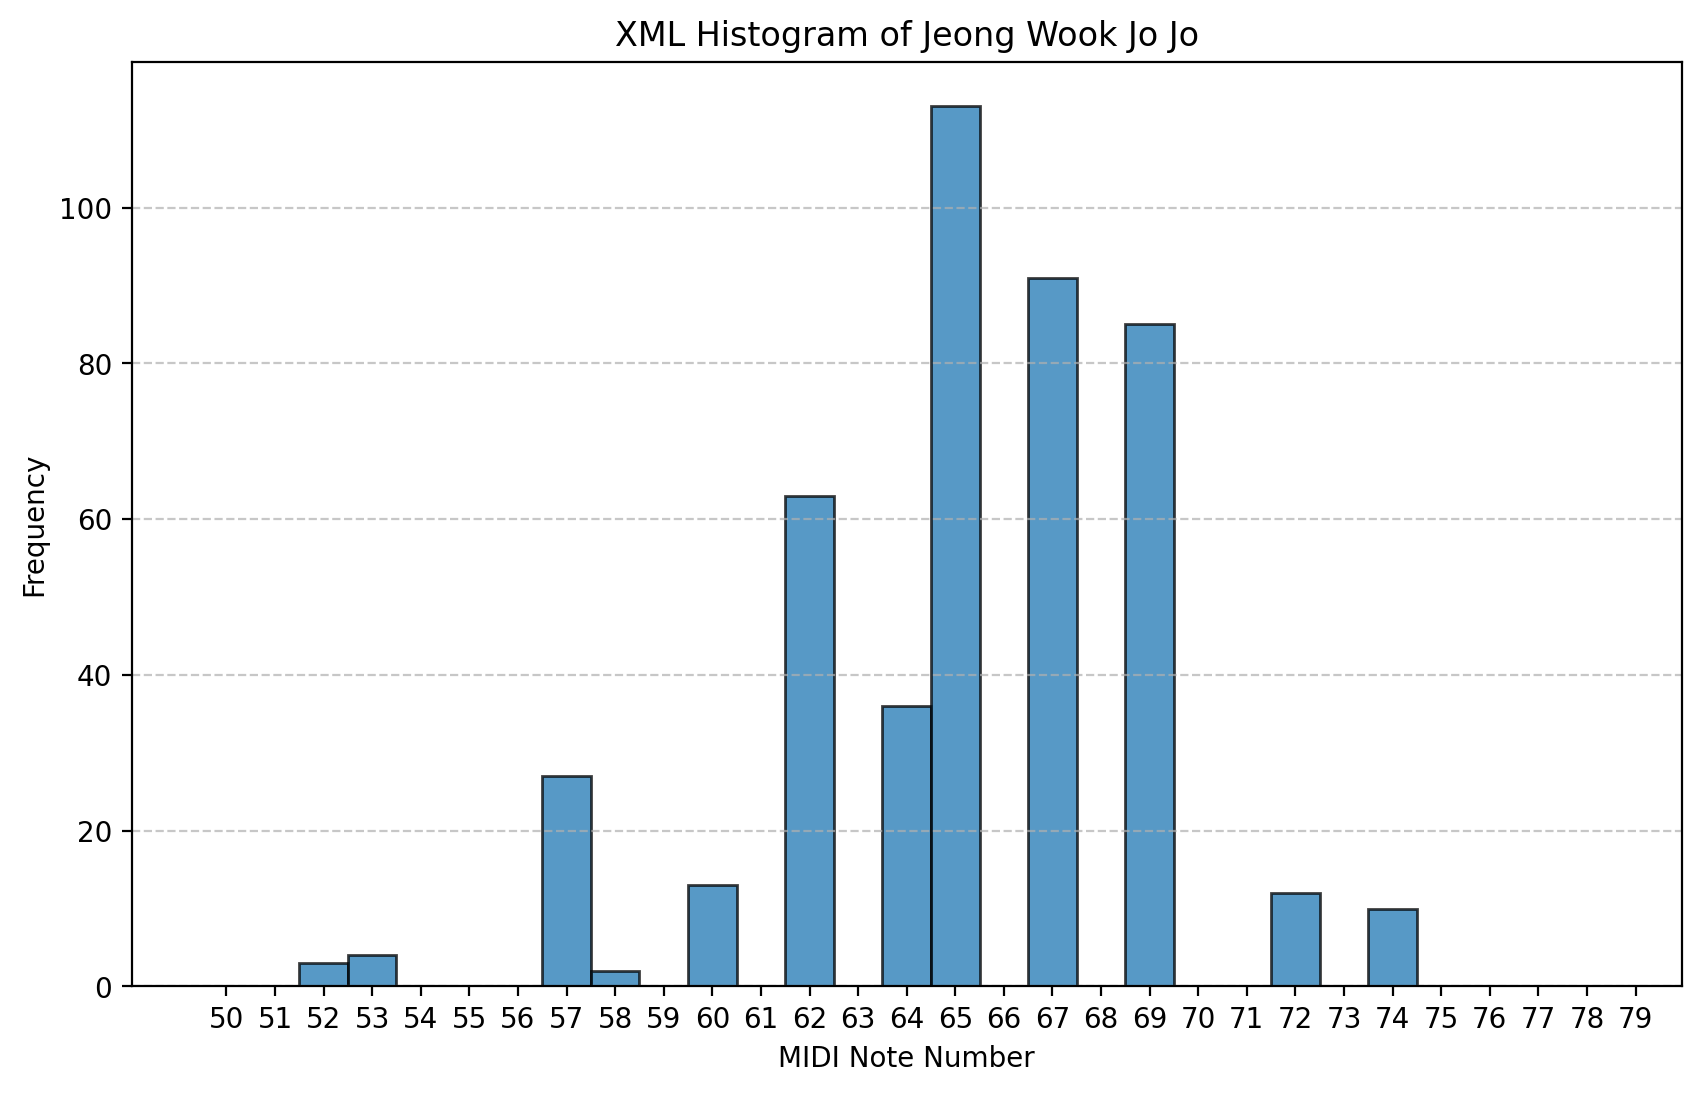

In [32]:
xml_file_path = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/28-1.musicxml"

midi_pitches = extract_midi_pitches_from_musicxml(xml_file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_pitches, bins=np.arange(50, 80) - 0.5, edgecolor="black", alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("XML Histogram of Jeong Wook Jo Jo")
plt.xticks(np.arange(50, 80))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# 조조 군사 점고 

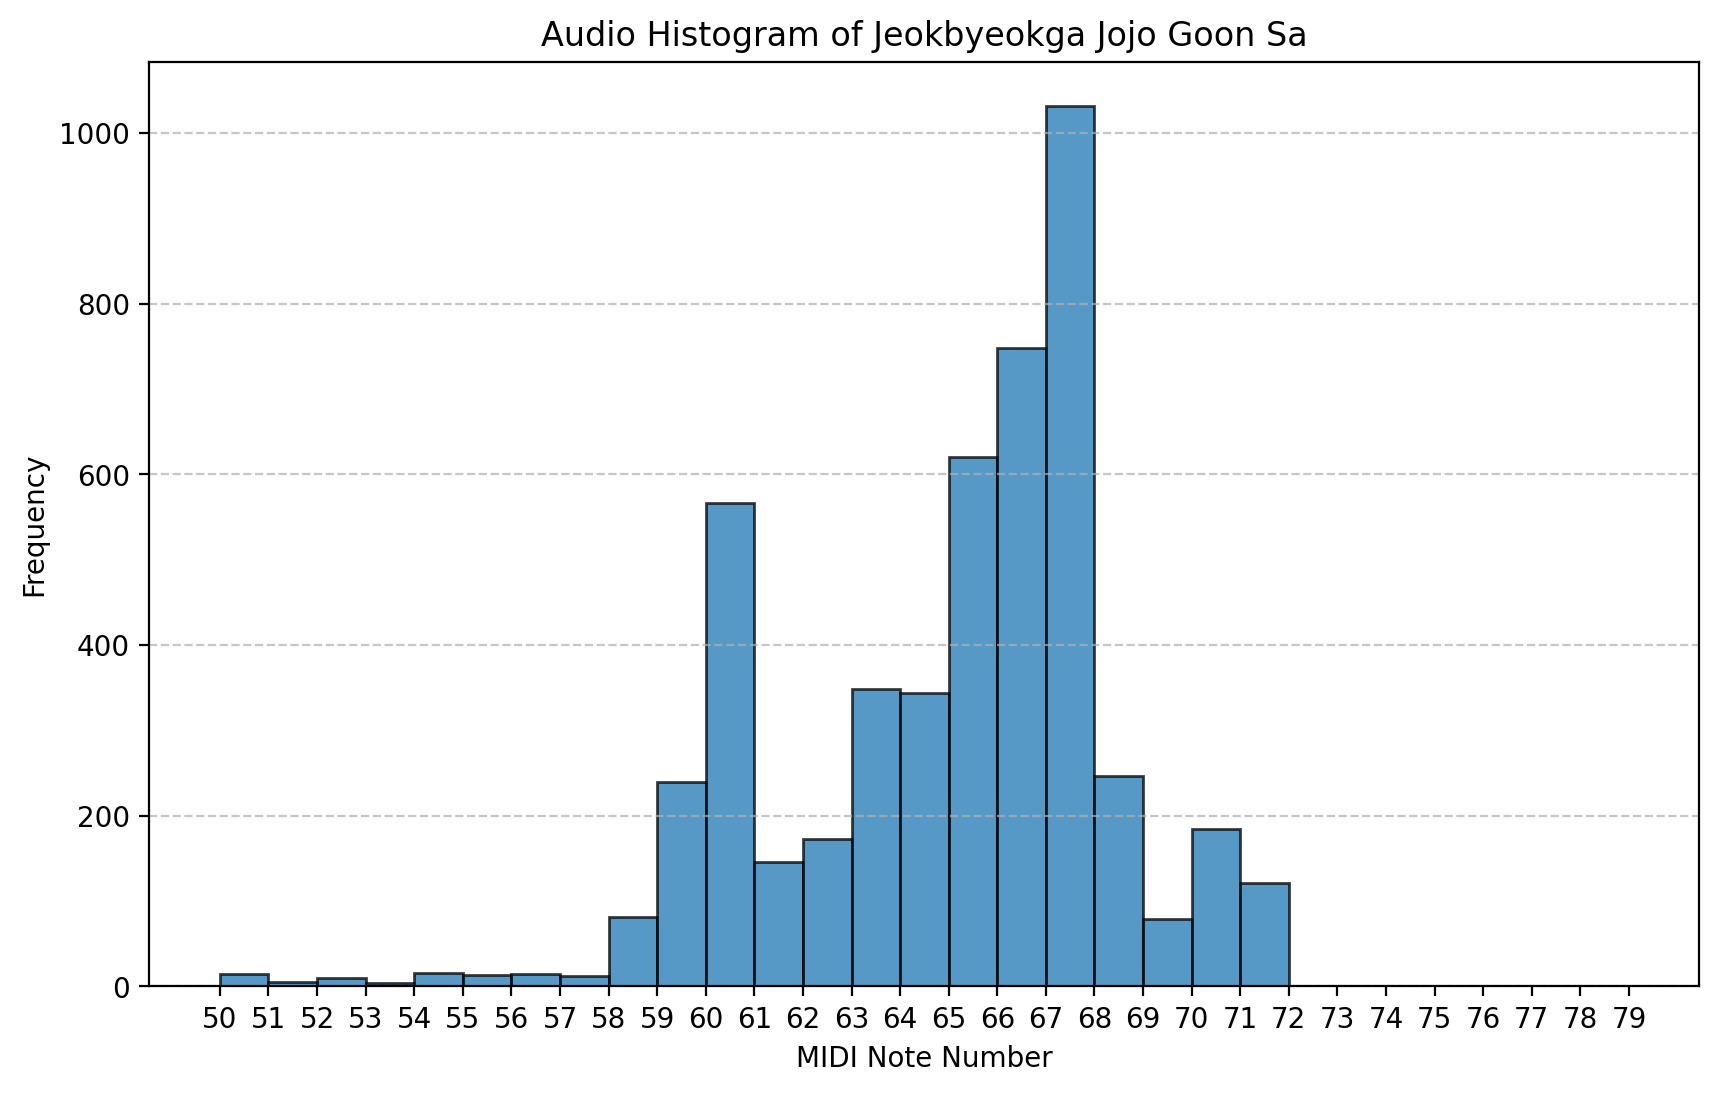

In [33]:
file_path = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/조조 군사 점고 골래종이전동다리구먹쇠 자진머리.csv'

midi_notes = get_midi_contour_from_csv(file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_notes, bins=np.arange(50, 80), edgecolor='black', alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("Audio Histogram of Jeokbyeokga Jojo Goon Sa")
plt.xticks(np.arange(50, 80))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

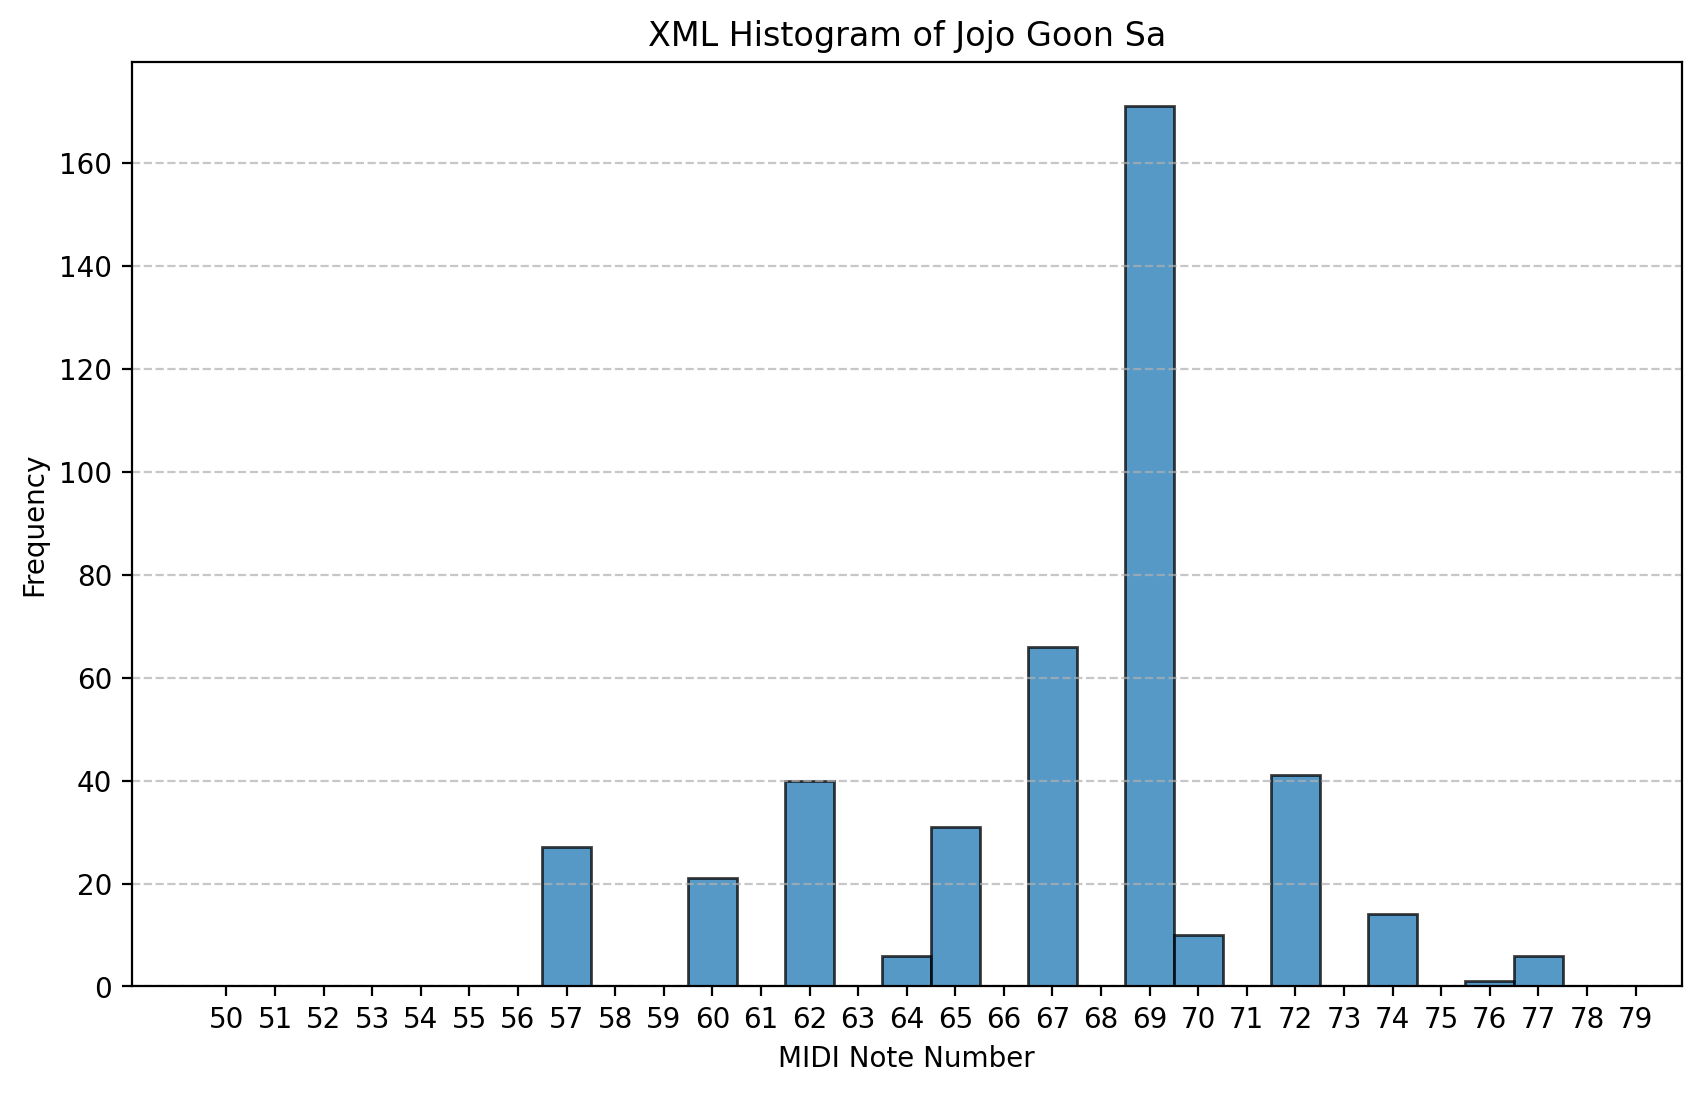

In [34]:
xml_file_path = "/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/31-4.musicxml"

midi_pitches = extract_midi_pitches_from_musicxml(xml_file_path)

plt.figure(figsize=(10, 6))
plt.hist(midi_pitches, bins=np.arange(50, 80) - 0.5, edgecolor="black", alpha=0.75)
plt.xlabel("MIDI Note Number")
plt.ylabel("Frequency")
plt.title("XML Histogram of Jojo Goon Sa")
plt.xticks(np.arange(50, 80))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


